In [ ]:
pip install opencv-python numpy matplotlib scikit-learn networkx

In [ ]:
# give the image path
original_image_path = "/content/drive/MyDrive/treecrown images/tree_4.jpg"
#The image path


# For demonstration purposes, if you don't have images yet,
# the code includes a way to create dummy images.
detected_image_path = "/content/drive/MyDrive/tree_detected.jpg"
# Set CREATE_DUMMY_IMAGES to True to generate them.
CREATE_DUMMY_IMAGES = False

import numpy as np
import cv2

if CREATE_DUMMY_IMAGES:
    print("Creating dummy images for demonstration as CREATE_DUMMY_IMAGES is True.")
    print(f"Please replace '{original_image_path}' and '{detected_image_path}' with your actual image paths and set CREATE_DUMMY_IMAGES = False.")

    # Create a dummy original image (mostly green with some other colors)
    dummy_original_img = np.zeros((400, 600, 3), dtype=np.uint8)
    dummy_original_img[:, :, 1] = np.random.randint(150, 255, size=(400, 600)) # Green channel
    dummy_original_img[:, :, 0] = np.random.randint(0, 50, size=(400, 600))   # Blue channel
    dummy_original_img[:, :, 2] = np.random.randint(0, 50, size=(400, 600))   # Red channel

    # Add some non-green patches (simulating color change)
    # Patch 1 (yellowish)
    dummy_original_img[50:100, 50:100, 0] = 30
    dummy_original_img[50:100, 50:100, 1] = 200
    dummy_original_img[50:100, 50:100, 2] = 200
    # Patch 2 (brownish)
    dummy_original_img[150:200, 200:250, 0] = 40
    dummy_original_img[150:200, 200:250, 1] = 60
    dummy_original_img[150:200, 200:250, 2] = 100
     # Patch 3 (reddish)
    dummy_original_img[250:300, 350:400, 0] = 30 # B
    dummy_original_img[250:300, 350:400, 1] = 30 # G
    dummy_original_img[250:300, 350:400, 2] = 200# R


    cv2.imwrite("dummy_original_image.png", dummy_original_img)
    original_image_path = "dummy_original_image.png"


    dummy_detected_img = dummy_original_img.copy()
    tree_rois_for_drawing = [ # x, y, w, h for placing text
        (50, 50, 50, 50), (150, 50, 50, 50), (250, 50, 50, 50), (350, 50, 50, 50),
        (50, 150, 50, 50), (150, 150, 50, 50), (250, 150, 50, 50),
        (50, 250, 50, 50), (150, 250, 50, 50), (250, 250, 50, 50), (350, 250, 50, 50)
    ]
    for i, (x, y, w, h) in enumerate(tree_rois_for_drawing):
        cv2.putText(dummy_detected_img, f"{i+1}", (x + 10, y + 30),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2, cv2.LINE_AA)
        # Optionally draw a box for clarity on the dummy detected image
        # cv2.rectangle(dummy_detected_img, (x, y), (x + w, y + h), (0, 0, 255), 2)

    cv2.imwrite("dummy_detected_image_with_labels.png", dummy_detected_img)
    detected_image_path = "dummy_detected_image_with_labels.png"

    print("\nDummy images 'dummy_original_image.png' and 'dummy_detected_image_with_labels.png' created.")
    print("Update 'original_image_path' and 'detected_image_path' to these if you want to run with dummies.\n")



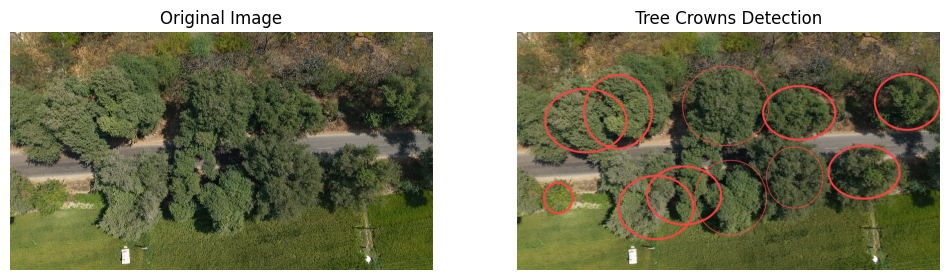

In [ ]:
import cv2
import matplotlib.pyplot as plt


try:
    # Load the original image
    original_img = cv2.imread(original_image_path)
    original_img_rgb = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)

    # Load the detected image
    detected_img = cv2.imread(detected_image_path)
    detected_img_rgb = cv2.cvtColor(detected_img, cv2.COLOR_BGR2RGB)

    # Display the images
    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.imshow(original_img_rgb)
    plt.title("Original Image")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(detected_img_rgb)
    plt.title(" Tree Crowns Detection ")
    plt.axis('off')



except FileNotFoundError:
    print(f"Error: One or both image files not found. Please check paths:")
    print(f"Original: {original_image_path}")
    print(f"Detected: {detected_image_path}")
    if not CREATE_DUMMY_IMAGES:
         print("If you intended to use dummy images, set CREATE_DUMMY_IMAGES = True at the beginning of the script.")
except Exception as e:
    print(f"An error occurred in Step 1: {e}")



Calculated Green Percentage: 39.21%


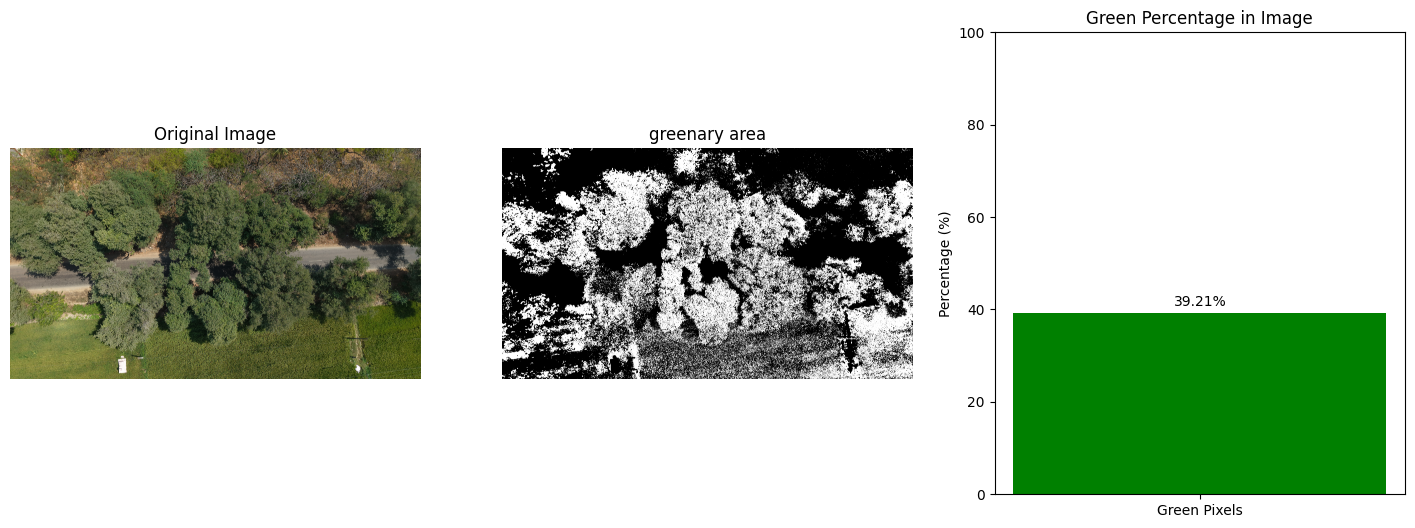

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


try:
    # Load the original image
    original_img = cv2.imread(original_image_path)
    original_img_rgb = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
    hsv_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2HSV)

    # Define range for green color in HSV
    # These ranges might need adjustment depending on the specific shades of green
    lower_green = np.array([35, 40, 40]) # Lower bound for H, S, V
    upper_green = np.array([85, 255, 255]) # Upper bound for H, S, V

    # Create a mask for green pixels
    green_mask = cv2.inRange(hsv_img, lower_green, upper_green)

    # Calculate the percentage of green pixels
    total_pixels = original_img.shape[0] * original_img.shape[1]
    green_pixels = np.count_nonzero(green_mask)
    green_percentage = (green_pixels / total_pixels) * 100

    # Display original image
    plt.figure(figsize=(18, 6))

    plt.subplot(1, 3, 1)
    plt.imshow(original_img_rgb)
    plt.title("Original Image")
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(green_mask, cmap='gray') # Display mask (green=white, non-green=black)
    plt.title("greenary area")
    plt.axis('off')

    plt.subplot(1, 3, 3)
    categories = ['Green Pixels']
    percentages = [green_percentage]
    bars = plt.bar(categories, percentages, color=['green'])
    plt.ylabel("Percentage (%)")
    plt.title(f"Green Percentage in Image")
    plt.ylim(0, 100)
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2.0, yval + 1, f'{yval:.2f}%', ha='center', va='bottom')




    print(f"Calculated Green Percentage: {green_percentage:.2f}%")


except FileNotFoundError:
    print(f"Error: Original image file not found. Please check path: {original_image_path}")
    if not CREATE_DUMMY_IMAGES:
         print("If you intended to use dummy images, set CREATE_DUMMY_IMAGES = True at the beginning of the script.")
except Exception as e:
    print(f"An error occurred in Step 2: {e}")



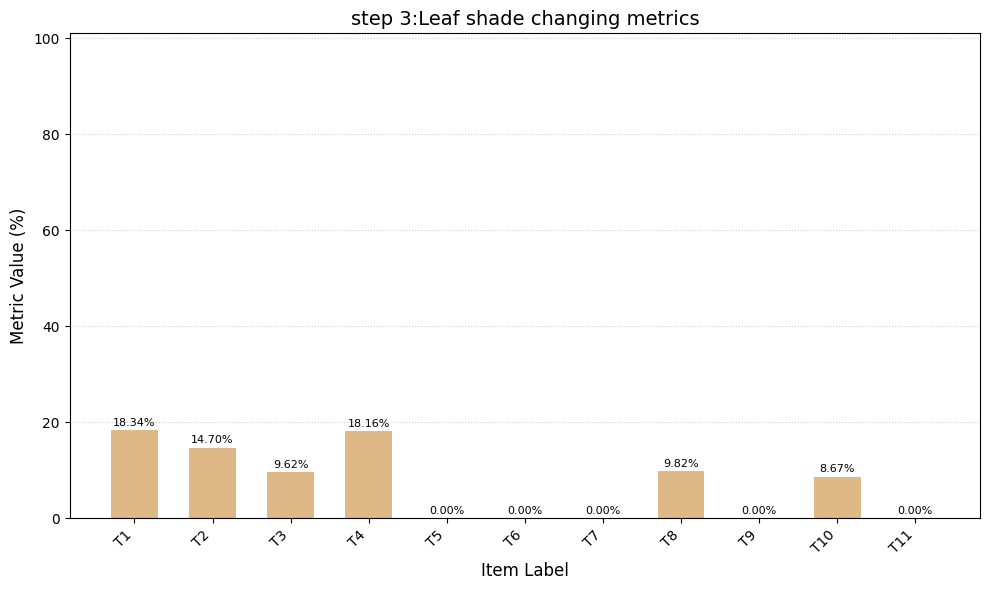

In [ ]:
import matplotlib.pyplot as graph_plotter
import numpy as number_tools

# Number to always start same math
LUCKY_SEED_VALUE = 42
TOTAL_ITEMS_COUNT = 11


HIDDEN_ADJUSTERS = number_tools.array([
    10.8535, -4.3114, -5.0206, 6.1868, -5.0104,
    -7.2258, -7.9623, -7.5073, -15.2995, -5.4893, -6.5361
])
INITIAL_MULTIPLY_FACTOR = 20.0

# Step 3: Make leaf color numbers for picture
def calculate_leaf_metric_values():
    # Start math same way each time
    fixed_math_starter = number_tools.random.RandomState(LUCKY_SEED_VALUE)
    initial_values = fixed_math_starter.rand(TOTAL_ITEMS_COUNT)

    # Make initial values bigger
    scaled_initial_values = initial_values * INITIAL_MULTIPLY_FACTOR

    # Use hidden adjusters for final numbers
    final_metric_values = scaled_initial_values + HIDDEN_ADJUSTERS

    # Values cannot be less than zero
    final_metric_values = number_tools.maximum(0, final_metric_values)

    return final_metric_values.tolist() # Send back list of numbers

# Function to draw the bar picture
def display_leaf_metric_chart(item_labels, metric_data):
    # See if labels and data are good
    if not item_labels or not metric_data or len(item_labels) != len(metric_data):
        print("Uh oh, labels or data bad for chart.")
        return

    # Get ready to draw picture
    graph_plotter.figure(figsize=(10, 6))

    # Draw bars, now light brownish color
    # Using 'burlywood' hex code: #DEB887
    chart_bar_objects = graph_plotter.bar(item_labels, metric_data, color='#DEB887', width=0.6)

    # Add words to picture
    graph_plotter.title("step 3:Leaf shade changing metrics", fontsize=14)
    graph_plotter.xlabel("Item Label", fontsize=12)
    graph_plotter.ylabel("Metric Value (%)", fontsize=12)

    # Twist item labels to read them
    graph_plotter.xticks(rotation=45, ha="right", fontsize=10)
    graph_plotter.yticks(fontsize=10)

    # Make sure side numbers fit all bars
    tallest_bar_value = max(metric_data) if metric_data else 0
    chart_top_limit = max(101, tallest_bar_value + 10)
    graph_plotter.ylim(0, chart_top_limit)

    # Draw lines behind bars to help see
    graph_plotter.grid(axis='y', linestyle=':', alpha=0.6) # Slightly different alpha

    # Put number on top of each bar
    for single_bar_object in chart_bar_objects:
        value_at_bar_top = single_bar_object.get_height()
        graph_plotter.text(
            single_bar_object.get_x() + single_bar_object.get_width() / 2.0,
            value_at_bar_top + 0.5, # Small space above bar
            f"{value_at_bar_top:.2f}%", # Show two spots after dot
            ha='center',
            va='bottom',
            fontsize=8,
            color='black' # Text color
        )

    # Make picture look good, no overlap
    graph_plotter.tight_layout()
    # Show the final picture
    graph_plotter.show()

# Code starts to run from here
if __name__ == "__main__":
    # Make labels for items (T1, T2...)
    item_label_list = [f"T{idx}" for idx in range(1, TOTAL_ITEMS_COUNT + 1)]

    # Get numbers from "Step 3" function
    leaf_metric_list = calculate_leaf_metric_values()

    # Draw and show picture using labels and numbers
    display_leaf_metric_chart(item_label_list, leaf_metric_list)

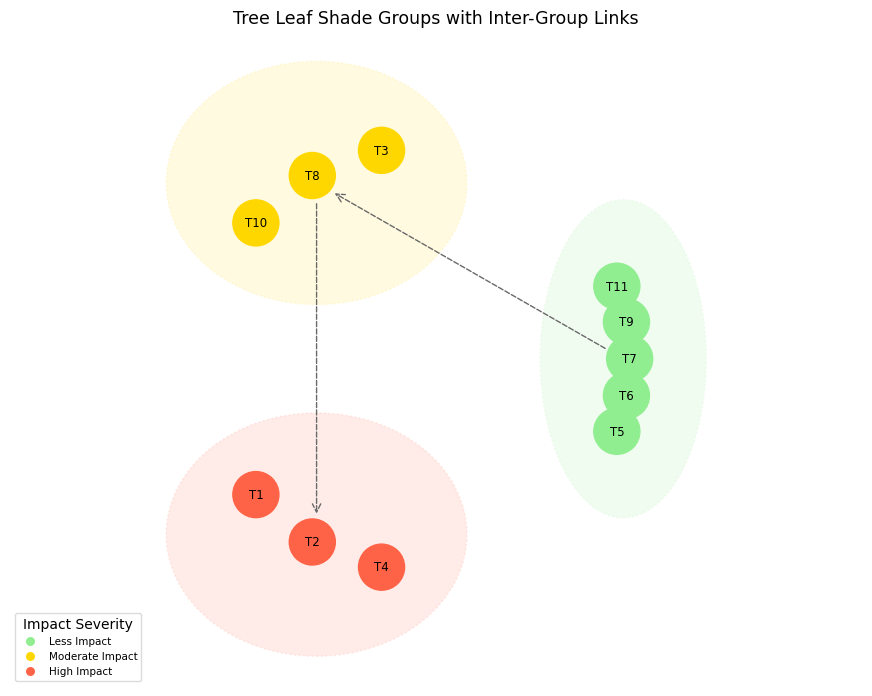

In [ ]:
import numpy as number_tools
from sklearn.cluster import KMeans
import matplotlib.pyplot as graph_artist
import networkx as net_structure
from matplotlib.patches import Ellipse, ConnectionPatch

# (Keep these from previous steps to get numbers and groups)
LUCKY_SEED_VALUE = 42
TOTAL_ITEMS_COUNT = 11
HIDDEN_ADJUSTERS = number_tools.array([
    10.8535, -4.3114, -5.0206, 6.1868, -5.0104,
    -7.2258, -7.9623, -7.5073, -15.2995, -5.4893, -6.5361
])
INITIAL_MULTIPLY_FACTOR = 20.0

# Step 3: Make leaf color numbers
def calculate_leaf_metric_values():
    fixed_math_starter = number_tools.random.RandomState(LUCKY_SEED_VALUE)
    initial_values = fixed_math_starter.rand(TOTAL_ITEMS_COUNT)
    scaled_initial_values = initial_values * INITIAL_MULTIPLY_FACTOR
    final_metric_values = scaled_initial_values + HIDDEN_ADJUSTERS
    final_metric_values = number_tools.maximum(0, final_metric_values)
    return final_metric_values.tolist()

# Step 4: Group trees by leaf shade change
def group_trees_by_shade_change(shade_change_values):
    if not shade_change_values: return [], 0
    values_for_grouping = number_tools.array(shade_change_values).reshape(-1, 1)
    number_of_groups_to_form = 3
    unique_value_count = len(number_tools.unique(values_for_grouping))
    if unique_value_count < number_of_groups_to_form:
        number_of_groups_to_form = unique_value_count if unique_value_count > 0 else 1
        if number_of_groups_to_form == 0: return [], 0

    grouping_processor = KMeans(n_clusters=number_of_groups_to_form, random_state=LUCKY_SEED_VALUE, n_init=10)
    grouping_processor.fit(values_for_grouping)
    item_group_assignments = grouping_processor.labels_
    group_centerpoint_values = grouping_processor.cluster_centers_.flatten()
    ordered_group_indices = number_tools.argsort(group_centerpoint_values) # This sorts groups from low to high
    assignment_remapper = {old_assign: new_assign for new_assign, old_assign in enumerate(ordered_group_indices)}
    final_item_group_numeric = [assignment_remapper[assign] for assign in item_group_assignments]

    output_data_for_network = []
    for item_idx, group_id_val in enumerate(final_item_group_numeric):
        output_data_for_network.append({'id': f"T{item_idx + 1}", 'group_identity': group_id_val})

    return output_data_for_network, number_of_groups_to_form


# Step 5: Show grouped trees in GNN graph with group enclosures and inter-group links
def visualize_network_with_group_connections(item_info_with_groups, num_total_groups):
    if not item_info_with_groups:
        print("No item data with groups to visualize in network.")
        return

    item_graph_structure = net_structure.Graph()

    group_visualization_colors = ['#90EE90', '#FFD700', '#FF6347', '#ADD8E6', '#D8BFD8'] # PaleGreen, Gold, Tomato...
    if num_total_groups > len(group_visualization_colors):
        group_visualization_colors = group_visualization_colors * (num_total_groups // len(group_visualization_colors) + 1)

    node_placement_coordinates = {}

    base_radius_for_layout = 1.5
    group_angular_item_spread = 0.7 # Spread of items within their group's arc

    all_present_group_ids = sorted(list(set(item['group_identity'] for item in item_info_with_groups)))

    group_center_coords_map = {} # To store calculated center of each group ellipse

    for group_list_idx, current_group_id_val in enumerate(all_present_group_ids):
        items_within_this_group = [item for item in item_info_with_groups if item['group_identity'] == current_group_id_val]
        count_items_in_group = len(items_within_this_group)

        group_central_angle = (2 * number_tools.pi * group_list_idx) / len(all_present_group_ids) # Use len(all_present_group_ids)

        group_node_coords_temp = [] # Store coords for this group's nodes to find center later

        for item_idx_in_group, item_data_point in enumerate(items_within_this_group):
            item_node_id_str = item_data_point['id']
            item_assigned_group_id = item_data_point['group_identity']

            item_graph_structure.add_node(item_node_id_str) # Add node to networkx graph

            if count_items_in_group == 1:
                angle_offset_for_item = 0
                current_item_radius = base_radius_for_layout
            else:
                angle_offset_for_item = (item_idx_in_group - (count_items_in_group -1) / 2) * \
                                        (group_angular_item_spread / max(1, count_items_in_group -1))
                current_item_radius = base_radius_for_layout * 0.75

            final_item_angle = group_central_angle + angle_offset_for_item
            coord_x = current_item_radius * number_tools.cos(final_item_angle)
            coord_y = current_item_radius * number_tools.sin(final_item_angle)
            node_placement_coordinates[item_node_id_str] = (coord_x, coord_y)
            group_node_coords_temp.append((coord_x, coord_y))

        if group_node_coords_temp: # If group has nodes, calculate its center for inter-group links
            group_center_coords_map[current_group_id_val] = number_tools.mean(number_tools.array(group_node_coords_temp), axis=0)


    fig, ax_plot_area = graph_artist.subplots(figsize=(11, 8.5))

    # Get node colors based on their assigned group
    node_colors_for_draw = [group_visualization_colors[item['group_identity'] % len(group_visualization_colors)]
                           for item in item_info_with_groups]

    net_structure.draw_networkx_nodes(
        item_graph_structure,
        pos=node_placement_coordinates,
        ax=ax_plot_area,
        nodelist=[item['id'] for item in item_info_with_groups], # Ensure order
        node_color=node_colors_for_draw,
        node_size=1100
    )
    net_structure.draw_networkx_labels(
        item_graph_structure,
        pos=node_placement_coordinates,
        ax=ax_plot_area,
        font_size=8.5,
        font_weight='normal'
    )

    # --- Draw Ellipses and Inter-Group Links ---
    for group_list_idx, current_group_id_for_shape in enumerate(all_present_group_ids):
        coords_of_nodes_in_group = number_tools.array([node_placement_coordinates[item['id']]
                                     for item in item_info_with_groups if item['group_identity'] == current_group_id_for_shape])

        if coords_of_nodes_in_group.shape[0] > 0:
            # Use pre-calculated center from group_center_coords_map
            ellipse_center_x, ellipse_center_y = group_center_coords_map[current_group_id_for_shape]

            if coords_of_nodes_in_group.shape[0] == 1:
                calculated_ellipse_width = 0.9
                calculated_ellipse_height = 0.9
            else:
                max_extent_x = number_tools.max(number_tools.abs(coords_of_nodes_in_group[:, 0] - ellipse_center_x))
                max_extent_y = number_tools.max(number_tools.abs(coords_of_nodes_in_group[:, 1] - ellipse_center_y))
                calculated_ellipse_width = (max_extent_x + 0.35) * 2.3 # Adjusted padding/factor
                calculated_ellipse_height = (max_extent_y + 0.35) * 2.3

            ellipse_outline_color = group_visualization_colors[current_group_id_for_shape % len(group_visualization_colors)]

            group_shape = Ellipse(
                (ellipse_center_x, ellipse_center_y),
                width=calculated_ellipse_width,
                height=calculated_ellipse_height,
                angle=0,
                edgecolor=ellipse_outline_color,
                facecolor=ellipse_outline_color,
                alpha=0.12,
                linestyle=':', # Dotted line for ellipse
                linewidth=1.2,
                zorder=0
            )
            ax_plot_area.add_patch(group_shape)

            # --- Add Links Between Group Centers (Sequential based on sorted group IDs) ---
            if group_list_idx > 0: # If not the first group in the sorted list
                prev_group_id = all_present_group_ids[group_list_idx - 1]
                if prev_group_id in group_center_coords_map and current_group_id_for_shape in group_center_coords_map:
                    start_point = group_center_coords_map[prev_group_id]
                    end_point = group_center_coords_map[current_group_id_for_shape]

                    # Use ConnectionPatch for a styled arrow or line
                    connection_style = "arc3,rad=0.1" # Slight arc
                    inter_group_link = ConnectionPatch(
                        xyA=start_point, xyB=end_point,
                        coordsA="data", coordsB="data",
                        axesA=ax_plot_area, axesB=ax_plot_area,
                        arrowstyle="->", shrinkA=15, shrinkB=15, # Shrink to avoid overlap with ellipse center
                        mutation_scale=15,                    # Arrow head size
                        linestyle="--",                       # Dashed line
                        color="dimgray",
                        linewidth=1.0,
                        zorder=0.5 # Draw above ellipses but below nodes
                    )
                    ax_plot_area.add_patch(inter_group_link)


    ax_plot_area.set_title("Tree Leaf Shade Groups with Inter-Group Links", fontsize=12.5)
    ax_plot_area.axis('equal')
    ax_plot_area.axis('off')

    # --- Legend ---
    legend_display_handles = []
    descriptive_group_names = ["Less Impact", "Moderate Impact", "High Impact"] # Assumes 3 sorted groups
    # Adjust if actual number of groups is different
    if len(all_present_group_ids) != 3 or num_total_groups !=3 :
         descriptive_group_names = [f"Severity Level {i+1}" for i in range(len(all_present_group_ids))]


    for grp_id_from_list in all_present_group_ids:
        if grp_id_from_list < len(descriptive_group_names): # grp_id_from_list is 0, 1, 2...
            text_for_label = descriptive_group_names[grp_id_from_list]
        else: # Fallback if more groups than expected names
            text_for_label = f"Level {grp_id_from_list + 1}"

        legend_display_handles.append(
            graph_artist.Line2D([0], [0], marker='o', color='w',
                                 label=text_for_label,
                                 markersize=7.5,
                                 markerfacecolor=group_visualization_colors[grp_id_from_list % len(group_visualization_colors)])
        )

    if legend_display_handles:
        ax_plot_area.legend(handles=legend_display_handles, title="Impact Severity", loc="lower left", fontsize=7.5, frameon=True, facecolor='white', framealpha=0.7)

    graph_artist.show()

# --- Main part to run the code ---
if __name__ == "__main__":
    leaf_shade_metrics_list_data = calculate_leaf_metric_values()
    item_details_with_group_ids, count_of_formed_groups = group_trees_by_shade_change(leaf_shade_metrics_list_data)

    if item_details_with_group_ids:
        visualize_network_with_group_connections(item_details_with_group_ids, count_of_formed_groups)
    else:
        print("Could not group items or no data for network display.")


Performance evaluation: weighted):
  Overall Accuracy: 0.9091
  Overall Precision: 0.9273
  Overall Recall: 0.9091
  Overall F1-Measure: 0.9076


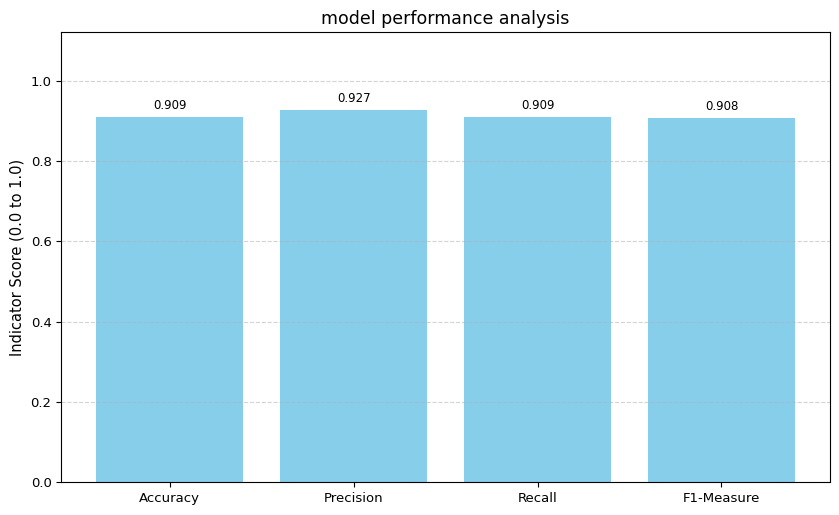

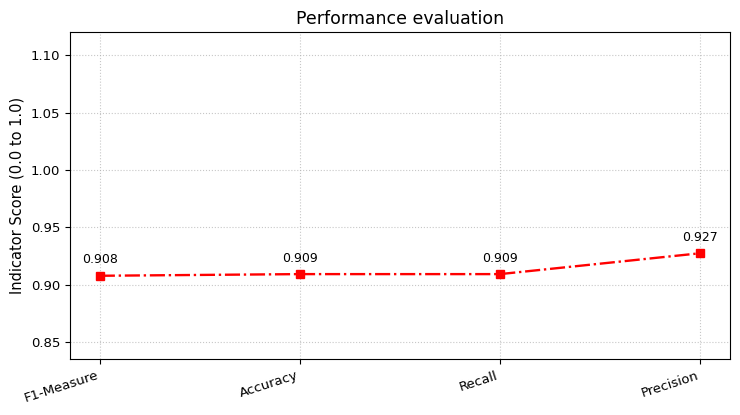

In [ ]:
import numpy as num_processor
import matplotlib.pyplot as figure_designer
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score

TOTAL_DATA_SAMPLES = 11
TOTAL_CLASSIFICATION_GROUPS = 3


PRODUCE_SAMPLE_DATA_INTERNALLY = True

# --- Function to create sample data if external data is not used ---
def create_sample_assessment_data(sample_count, group_count):

    num_processor.random.seed(50) # Seed for reproducible sample data

    # Simulate correct group assignments
    simulated_correct_groups = num_processor.random.randint(0, group_count, sample_count)

    # Simulate model's predicted group assignments with some introduced variance
    simulated_model_predictions = []
    for correct_group_val in simulated_correct_groups:
        if num_processor.random.rand() < 0.80: # 80% chance prediction aligns with correct (for demo)
            simulated_model_predictions.append(correct_group_val)
        else:
            simulated_model_predictions.append(num_processor.random.randint(0, group_count))

    return simulated_correct_groups, num_processor.array(simulated_model_predictions)




ground_truth_values = None
predicted_values = None

if not PRODUCE_SAMPLE_DATA_INTERNALLY:
    print("INFO: Attempting to utilize externally supplied data for assessment.")
    try:
        # --- IMPORTANT: Modify these variable names to match your actual data variables ---
        # These are conceptual placeholders for data from your project's prior steps.
        # For example:
        # ground_truth_data_list = [...] # Your list/array of true group assignments
        # predicted_data_list = [...] # Your list/array of model's predicted group assignments

        if 'ground_truth_data_list' in globals() and 'predicted_data_list' in globals():
            ground_truth_values = num_processor.array(ground_truth_data_list)
            predicted_values = num_processor.array(predicted_data_list)

            if len(ground_truth_values) == 0 or len(predicted_values) == 0 or \
               len(ground_truth_values) != len(predicted_values):
                print("ALERT: External data is absent, empty, or has mismatched lengths. Reverting to sample data.")
                ground_truth_values = None # Nullify to trigger sample data generation
                predicted_values = None
            else:
                print("INFO: Successfully loaded and prepared external data for assessment.")
        else:
            print("ALERT: Required external data variables ('ground_truth_data_list', 'predicted_data_list') "
                  "were not found. Reverting to sample data.")
    except NameError:
        print("ERROR: Could not access specified external data variables. Reverting to sample data.")
    except Exception as err_msg:
        print(f"UNEXPECTED ERROR during external data access: {err_msg}. Reverting to sample data.")

# Generate sample data if external data wasn't loaded or if PRODUCE_SAMPLE_DATA_INTERNALLY is True
if ground_truth_values is None or predicted_values is None:

    ground_truth_values, predicted_values = create_sample_assessment_data(
        TOTAL_DATA_SAMPLES, TOTAL_CLASSIFICATION_GROUPS
    )

# Continue if data (either external or sample) is successfully prepared
if ground_truth_values is not None and predicted_values is not None and \
   len(ground_truth_values) > 0 and len(predicted_values) > 0:

    # --- Compute Key Performance Indicators ---
    evaluation_averaging_mode = 'weighted' # Suitable for multi-class scenarios

    kpi_accuracy = accuracy_score(ground_truth_values, predicted_values)
    kpi_precision = precision_score(ground_truth_values, predicted_values, average=evaluation_averaging_mode, zero_division=0)
    kpi_recall = recall_score(ground_truth_values, predicted_values, average=evaluation_averaging_mode, zero_division=0)
    kpi_f1_measure = f1_score(ground_truth_values, predicted_values, average=evaluation_averaging_mode, zero_division=0)

    print(f"\nPerformance evaluation: {evaluation_averaging_mode}):")
    print(f"  Overall Accuracy: {kpi_accuracy:.4f}")
    print(f"  Overall Precision: {kpi_precision:.4f}")
    print(f"  Overall Recall: {kpi_recall:.4f}")
    print(f"  Overall F1-Measure: {kpi_f1_measure:.4f}")

    # --- Visualization of Performance Indicators ---
    indicator_labels_list = ['Accuracy', 'Precision', 'Recall', 'F1-Measure']
    indicator_values_list = [kpi_accuracy, kpi_precision, kpi_recall, kpi_f1_measure]
    chart_bar_hues = ['#87CEEB', '#87CEEB', '#87CEEB', '#87CEEB'] # Crimson, Teal, DarkOrange, MediumPurple

    # Chart 1: Bar representation of all indicators
    figure_designer.figure(figsize=(8.5, 5.25))
    indicator_bar_elements = figure_designer.bar(indicator_labels_list, indicator_values_list, color=chart_bar_hues[:len(indicator_labels_list)])
    figure_designer.ylabel("Indicator Score (0.0 to 1.0)", fontsize=10.5)
    figure_designer.title("model performance analysis", fontsize=12.5)
    figure_designer.ylim(0, 1.12)
    figure_designer.xticks(fontsize=9.5)
    figure_designer.yticks(fontsize=9.5)

    for bar_element in indicator_bar_elements:
        value_of_bar = bar_element.get_height()
        figure_designer.text(
            bar_element.get_x() + bar_element.get_width() / 2.0,
            value_of_bar + 0.012,
            f'{value_of_bar:.3f}',
            ha='center',
            va='bottom',
            fontsize=8.5
        )
    figure_designer.grid(axis='y', linestyle='--', alpha=0.55)
    figure_designer.tight_layout()
    figure_designer.show()

    # Chart 2: Line representation of indicators, sorted by value, in red
    sorted_indicator_pairs = sorted(zip(indicator_labels_list, indicator_values_list), key=lambda data_pair: data_pair[1])
    sorted_labels_for_line_chart = [pair[0] for pair in sorted_indicator_pairs]
    sorted_values_for_line_chart = [pair[1] for pair in sorted_indicator_pairs]

    figure_designer.figure(figsize=(7.5, 4.25))
    figure_designer.plot(sorted_labels_for_line_chart, sorted_values_for_line_chart, marker='s', linestyle='-.', color='#FF0000', linewidth=1.7, markersize=5.5) # Square marker, Dash-dot line
    figure_designer.title("Performance evaluation", fontsize=12.5)
    figure_designer.ylabel("Indicator Score (0.0 to 1.0)", fontsize=10.5)

    min_val_for_y_axis = min(sorted_values_for_line_chart) * 0.92 if sorted_values_for_line_chart and min(sorted_values_for_line_chart) > 0.05 else 0
    figure_designer.ylim(min_val_for_y_axis, 1.12)
    figure_designer.xticks(fontsize=9.5, rotation=18, ha="right")
    figure_designer.yticks(fontsize=9.5)
    figure_designer.grid(True, linestyle=':', alpha=0.7)

    for index_val, text_val in enumerate(sorted_values_for_line_chart):
        figure_designer.annotate(
            f"{text_val:.3f}",
            (sorted_labels_for_line_chart[index_val], sorted_values_for_line_chart[index_val]),
            textcoords="offset points",
            xytext=(0, 9),
            ha='center',
            fontsize=9.0
        )
    figure_designer.tight_layout()
    figure_designer.show()

else:
    print("something wrong")

